# Copernicus Solar Forecasting - Machine Learning Project

## Introduction générale

Ce projet s’inscrit dans le cadre du challenge Copernicus de prévision solaire à court terme. L’objectif est de prédire les **4 prochaines cartes de GHI** (Global Horizontal Irradiance) aux horizons **t+15, t+30, t+45 et t+60 minutes**, à partir des **4 dernières images staellites observées** issues du programme Copernicus, ainsi que de variables physiques auxiliaires. Le challenge porte sur une **région d’intérêt de 51×51 pixels**, incluse dans une région d’observation plus large de **81×81 pixels**, afin de tenir compte du déplacement des nuages avant leur entrée dans la zone prédite. Cette formulation fait du problème une **régression spatio-temporelle sur séquences d’images**, avec une forte composante physique liée aux conditions de ciel clair et à la géométrie solaire.

Les enjeux applicatifs sont importants. Une meilleure prévision intrajournalière du rayonnement solaire permet une meilleure intégration du photovoltaïque dans les réseaux électriques, en réduisant l’incertitude sur la production future. Le sujet est donc à la fois un problème de machine learning et un problème énergétique concret.

D’un point de vue méthodologique, le projet suit la logique attendue dans le cours :  
1. comprendre la structure des données ;  
2. construire des variables explicatives pertinentes ;  
3. définir une baseline crédible ;  
4. comparer plusieurs familles de modèles ;  
5. interpréter les résultats ;  
6. discuter les limites et les perspectives.

Nous utilisons :
- des approches **baseline physiques (persistance)**
- des modèles **machine learning tabulaires**
- des modèles **deep learning spatio-temporels (CNN / ConvLSTM)**

L’objectif est d’améliorer la précision des prévisions afin de mieux anticiper la production d’énergie photovoltaïque.

# Contexte et problématique

## Enjeux énergétiques

La production d’énergie solaire est fortement dépendante de la nébulosité, ce qui introduit une variabilité importante.

Des prévisions précises à court terme permettent :
- une meilleure gestion des réseaux électriques
- une meilleure intégration du photovoltaïque
- une réduction des coûts liés aux déséquilibres production / consommation

---

## Données Copernicus

Les données proviennent de satellites géostationnaires (MSG) fournissant :
- des images toutes les 15 minutes
- une résolution spatiale de ~3 km
- des cartes d’irradiance solaire (GHI)

Le problème consiste à exploiter ces séquences d’images pour prédire les images futures.

---

## Problématique ML

On cherche à approximer une fonction :

GHI(t+Δt) = f(GHI(t), GHI(t-15), ..., variables physiques)

avec :
- une forte dimension spatiale
- une dépendance temporelle
- une dynamique liée aux nuages

Il s’agit donc d’un **problème de régression spatio-temporelle complexe** :contentReference[oaicite:1]{index=1}

# Description des données

## Variables d’entrée

Les données d’entrée comprennent :

- **GHI** : séquence des 4 dernières images (81×81)
- **CLS (clear-sky)** : GHI théorique sans nuages (passé + futur)
- **SZA** : angle zénithal solaire
- **SAA** : angle azimutal solaire

---

## Variable cible

- 4 images futures de GHI
- horizons : t+15, t+30, t+45, t+60
- taille : 51×51 (région d’intérêt)

---

## Difficultés

- très haute dimension
- dépendance spatiale forte
- dynamique non linéaire des nuages
- bruit et incertitude physique

## Plan méthodologique et choix de validation

Le notebook est organisé en plusieurs blocs complémentaires :

- **Bloc A** : baselines physiques et statistiques ;
- **Bloc B** : modèles supervisés tabulaires ;
- **Bloc C** : approche non supervisée par clustering ;
- **Bloc D** : deep learning spatio-temporel ;
- **Bloc E** : interprétation des modèles.

Le split est réalisé de manière **chronologique** entre entraînement et validation. Ce choix est essentiel ici, car nous sommes dans un cadre temporel : un découpage aléatoire introduirait un risque de fuite d’information et produirait une estimation trop optimiste des performances. Le code de préprocessing implémente explicitement ce split temporel avec une fraction de validation de 20 %. :contentReference[oaicite:6]{index=6}

Enfin, la baseline de référence retenue pour tous les skill scores est la **persistance CSI**. Ce choix est judicieux car il incorpore déjà une information physique importante, à savoir l’irradiance de ciel clair future. Il s’agit donc d’une baseline plus exigeante qu’une simple persistance brute sur GHI. :contentReference[oaicite:7]{index=7}

## Note sur le protocole train / validation / test

Le challenge fournit un jeu d’entraînement et un jeu de test séparé. Dans ce notebook, le **jeu de test officiel est conservé intact** et n’est jamais utilisé pour le choix des modèles. La sélection des hyperparamètres et la comparaison intermédiaire sont réalisées sur une **validation chronologique** construite à l’intérieur du train, afin de respecter la structure temporelle du problème. Une fois le modèle final retenu, le même pipeline peut être appliqué au `X_test` officiel pour produire une soumission hors échantillon. 

## 0. Setup

In [20]:
# ============================================================
# Google Colab setup (décommenter uniquement sur Colab)
# ============================================================

# from pathlib import Path
# import os
# import sys

# IN_COLAB = "google.colab" in sys.modules

# if IN_COLAB:
#     from google.colab import drive
#     drive.mount("/content/drive", force_remount=True)

#     # Adapter ce chemin à l'emplacement exact du projet dans ton Drive
#     ROOT = Path("/content/drive/MyDrive/coplan/coproject/copernicus_solar_forecasting")
#     os.chdir(ROOT)

#     if str(ROOT) not in sys.path:
#         sys.path.insert(0, str(ROOT))

#     # Dépendances utiles si nécessaire
#     !pip -q install shap
#     !pip -q install tensorflow

#     print("Colab setup OK")
#     print("Working directory:", ROOT)

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import ParameterGrid
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from config import FORECAST_HORIZONS_MINUTES, INPUT_VARIABLES
from src.baselines import mean_image_baseline, persistence_csi_baseline, persistence_last_ghi_baseline
from src.data_loading import open_processed_profile, prepare_processed_profile, processed_profile_exists
from src.deep_learning import (
    build_convlstm_residual_model,
    build_small_residual_cnn,
    fit_mlp_residual_mean,
    has_tensorflow,
    prepare_cnn_training_data,
    prepare_convlstm_training_data,
    target_from_channels_last,
    add_residual_mean_to_baseline,
)
from src.eda import descriptive_stats, target_horizon_stats
from src.experiment_io import list_saved_outputs, load_saved_predictions, save_prediction_bundle
from src.features import (
    build_advanced_features,
    build_exogenous_features,
    build_physical_inputs,
    build_spatial_dynamics_features,
    build_spatial_feature_tensor,
    build_tabular_features,
)
from src.interpretation import (
    compute_tree_shap_values,
    model_feature_importances,
    permutation_importance_multioutput,
)
from src.metrics import (
    build_model_diagnostics,
    cluster_balance_report,
    cluster_quality,
    evaluate_model_bundle,
    global_metrics_row,
    metrics_by_cluster,
    rmse,
    spatial_mean_residual,
)
from src.motion import advective_csi_baseline, estimate_motion_vectors, has_opencv
from src.preprocessing import temporal_train_validation_split
from src.texture import build_texture_features
from src.visualization import (
    horizon_titles,
    plot_cluster_metric,
    plot_forecast_triplet,
    plot_metric_by_horizon,
    plot_motion_summary,
    plot_sequence,
)
from models.models_tabular import (
    fit_elasticnet_multioutput,
    fit_extra_trees_multioutput,
    fit_hist_gb_multioutput,
    fit_random_forest_multioutput,
    fit_ridge_multioutput,
    patchwise_predictions_to_map,
    patchwise_target_means,
)

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [ ]:
RANDOM_STATE = 42
PROFILE = "full"  # "dev", "sample" ou "full"
MAIN_REFERENCE_NAME = "persistence_csi"

RUN_FAST = PROFILE == "dev"
RUN_LOCAL_ML = True
RUN_DEEP_LEARNING = False  # mettre True sur Colab
RUN_XAI = True
RUN_SHAP = True

SAVE_OUTPUTS = False
LOAD_SAVED_OUTPUTS = True
OVERWRITE_OUTPUTS = False
OUTPUT_DIR = ROOT / "reports" / "model_outputs" / "final_beta" / PROFILE
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

np.random.seed(RANDOM_STATE)
print("ROOT:", ROOT)
print("OUTPUT_DIR:", OUTPUT_DIR)

ROOT: c:\Users\alixg\OneDrive - Université Paris-Dauphine\M2 Quant\Machine Learning\projet\copernicus_solar_forecasting
OUTPUT_DIR: c:\Users\alixg\OneDrive - Université Paris-Dauphine\M2 Quant\Machine Learning\projet\copernicus_solar_forecasting\reports\model_outputs\final_beta\full


In [21]:
# Pour un run Colab orienté deep learning :
# RUN_LOCAL_ML = True
# RUN_DEEP_LEARNING = True
# SAVE_OUTPUTS = True
# LOAD_SAVED_OUTPUTS = True
#
# Puis relancer la comparaison finale après sauvegarde/rechargement des prédictions.

## 1. Chargement, split et EDA rapide

In [3]:
if not processed_profile_exists(PROFILE, split="train"):
    prepare_processed_profile(PROFILE, split="train", overwrite=False)

data = open_processed_profile(PROFILE, split="train", variables=INPUT_VARIABLES, mmap_mode=None)
arrays = {name: np.asarray(values, dtype=np.float32) for name, values in data["X"].items()}
y = np.asarray(data["y"], dtype=np.float32)

train_idx, val_idx = temporal_train_validation_split(len(y), validation_fraction=0.2)
train_arrays_raw = {name: values[train_idx] for name, values in arrays.items()}
val_arrays_raw = {name: values[val_idx] for name, values in arrays.items()}
train_target = y[train_idx]
val_target = y[val_idx]

print(f"Profil: {PROFILE}")
print(f"Samples: total={len(y)}, train={len(train_idx)}, validation={len(val_idx)}")
print({name: value.shape for name, value in arrays.items()})
display(descriptive_stats(arrays, y))
display(target_horizon_stats(y))

Profil: full
Samples: total=1845, train=1476, validation=369
{'GHI': (1845, 4, 51, 51), 'CLS': (1845, 8, 51, 51), 'SZA': (1845, 8, 51, 51), 'SAA': (1845, 8, 51, 51)}


,variable,shape,mean,std,min,median,max
0,GHI,"(1845, 4, 51, 51)",501.326935,273.921478,8.040000,499.649994,1099.449951
1,CLS,"(1845, 8, 51, 51)",576.162415,253.484070,34.450001,567.429993,1119.270020
2,SZA,"(1845, 8, 51, 51)",175.404953,60.614697,65.910004,173.330002,285.309998
3,SAA,"(1845, 8, 51, 51)",52.772953,17.380068,12.980000,55.619999,85.449997
4,target,"(1845, 4, 51, 51)",510.516968,261.338043,7.330000,472.369995,1093.689941


,horizon_min,mean,std,min,median,max
0,15,511.794189,258.839478,19.34,486.140015,1093.689941
1,30,512.276611,258.324799,14.93,472.820007,1084.849976
2,45,510.756714,261.177277,10.13,457.950012,1077.020020
3,60,507.240509,266.892487,7.33,469.109985,1087.630005


## 1.bis. Lecture des statistiques descriptives

Le jeu `full` contient **1845 séquences**, découpées en **1476 observations d’entraînement** et **369 observations de validation**. Les tenseurs ont bien les dimensions attendues pour le challenge : `GHI` en 4 pas de temps passés, `CLS`, `SZA` et `SAA` en 8 pas de temps, et une cible de forme `(4, 51, 51)`. Cela confirme que le pipeline de chargement et de preprocessing est cohérent avec la définition du problème.

Les statistiques descriptives montrent que le **GHI observé** a une moyenne inférieure au **CLS**. C’est physiquement attendu : le ciel clair représente l’irradiance théorique sans nuage, alors que le GHI réel est atténué par la nébulosité. Cette observation justifie directement l’introduction du **Clear Sky Index (CSI = GHI / CLS)** dans la suite du projet. La cible a une moyenne légèrement supérieure à celle du GHI passé, mais reste du même ordre de grandeur, ce qui suggère une continuité temporelle exploitable par les baselines de persistance.

Les statistiques par horizon montrent une moyenne globale assez stable entre **t+15** et **t+60**, mais une dispersion qui tend à augmenter quand l’horizon s’éloigne. Cela indique que le niveau moyen reste comparable, tandis que l’incertitude sur la structure spatiale future augmente avec le temps. On s’attend donc naturellement à une hausse du RMSE aux horizons les plus lointains.

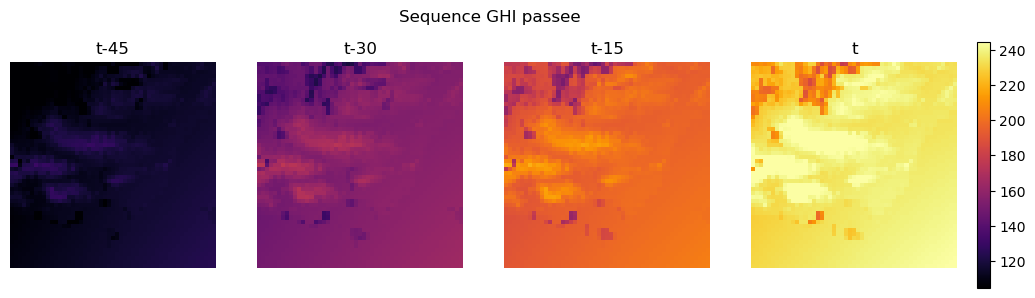

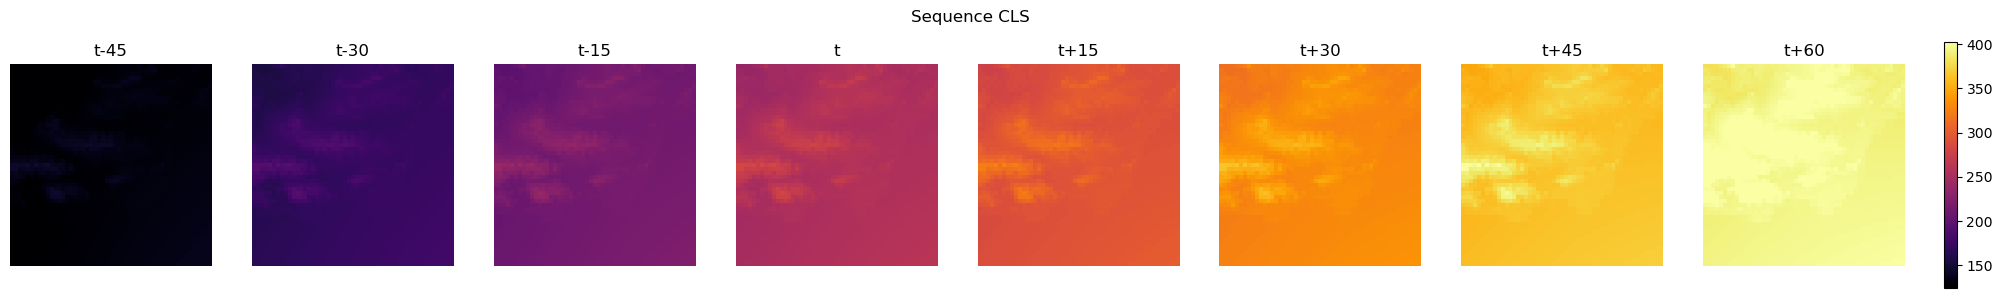

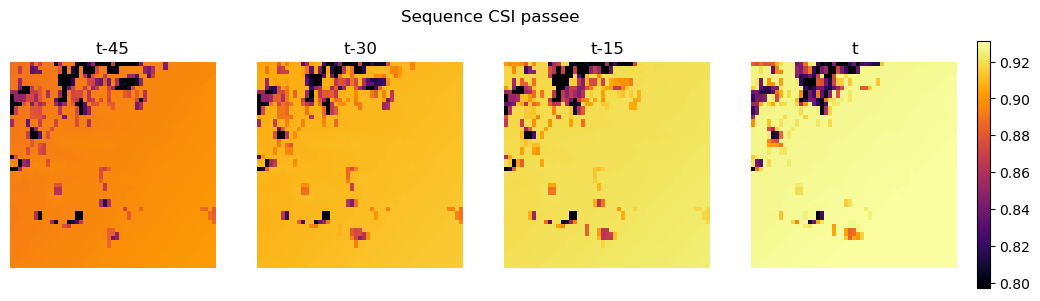

In [4]:
sample_id = 0
sample_phys = build_physical_inputs({name: values[[sample_id]] for name, values in arrays.items()}, keep_raw_ghi=True)
sample_csi = sample_phys["CSI"][0]

plot_sequence(arrays["GHI"][sample_id], titles=["t-45", "t-30", "t-15", "t"], suptitle="Sequence GHI passee")
plt.show()
plot_sequence(arrays["CLS"][sample_id], titles=["t-45", "t-30", "t-15", "t", "t+15", "t+30", "t+45", "t+60"], suptitle="Sequence CLS")
plt.show()
plot_sequence(sample_csi, titles=["t-45", "t-30", "t-15", "t"], suptitle="Sequence CSI passee")
plt.show()

## 1.ter. Lecture physique des séquences visualisées

Les visualisations de séquences permettent de comprendre pourquoi ce problème est difficile. Les cartes GHI passées montrent à la fois une composante de niveau global d’irradiance et une composante de structure spatiale liée à la présence, à l’épaisseur et au déplacement des nuages. Les cartes CLS jouent ici un rôle de référence physique : elles permettent de distinguer ce qui relève de la géométrie solaire de ce qui relève réellement de la couverture nuageuse.

La séquence de **CSI** est particulièrement utile pour cette lecture. En divisant le GHI par le ciel clair, on normalise une partie de la variabilité déterministe liée au soleil. Le problème devient alors plus proche d’une modélisation de l’effet nuageux pur. C’est une transformation très pertinente dans un contexte d’énergie solaire, car elle rend la série plus comparable d’un instant à l’autre et facilite la modélisation des résidus autour d’une référence physique.

## 2. Construction des features communes

Vent U/V absent des fichiers: pas de features exogenes ajoutees.
OpenCV disponible: False
Feature matrix: (1476, 628)


,count,mean,std,min,25%,50%,75%,max
phys_CSI_mean_t0,1476.0,0.880412,0.124901,0.143136,0.846034,0.921615,0.964935,1.002780
phys_CSI_std_t0,1476.0,0.082471,0.069276,0.001421,0.024556,0.063255,0.127203,0.317049
phys_CSI_min_t0,1476.0,0.527376,0.259031,0.093864,0.292224,0.536363,0.757906,0.982073
phys_CSI_max_t0,1476.0,0.964526,0.043581,0.446953,0.957681,0.976410,0.991968,1.020442
phys_CSI_mean_t1,1476.0,0.880345,0.128423,0.147248,0.844999,0.922198,0.965784,1.002667
phys_CSI_std_t1,1476.0,0.084777,0.071150,0.001376,0.024935,0.064601,0.132382,0.322224
phys_CSI_min_t1,1476.0,0.520147,0.266480,0.094576,0.268508,0.535634,0.752697,0.981175
phys_CSI_max_t1,1476.0,0.967008,0.039864,0.475089,0.956523,0.976917,0.991954,1.019928
phys_CSI_mean_t2,1476.0,0.881551,0.128337,0.153504,0.848248,0.922083,0.965704,1.002711
phys_CSI_std_t2,1476.0,0.085331,0.071600,0.001110,0.025301,0.066161,0.131844,0.316081


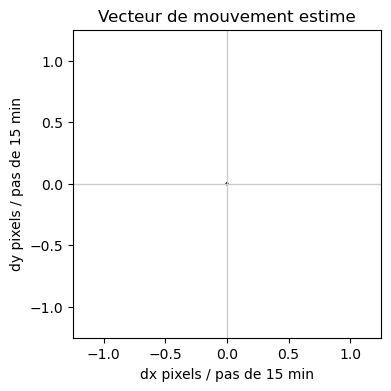

In [5]:
train_phys = build_physical_inputs(train_arrays_raw, keep_raw_ghi=True, encode_angles=True)
val_phys = build_physical_inputs(val_arrays_raw, keep_raw_ghi=True, encode_angles=True)

train_motion = estimate_motion_vectors(train_phys["CSI"], use_farneback=None).add_prefix("flow_")
val_motion = estimate_motion_vectors(val_phys["CSI"], use_farneback=None).add_prefix("flow_")
train_texture = build_texture_features(train_phys, variable="CSI", time_index=-1).add_prefix("tex_")
val_texture = build_texture_features(val_phys, variable="CSI", time_index=-1).add_prefix("tex_")
train_spatial_dyn = build_spatial_dynamics_features(train_arrays_raw).add_prefix("spdyn_")
val_spatial_dyn = build_spatial_dynamics_features(val_arrays_raw).add_prefix("spdyn_")
train_exogenous = build_exogenous_features(train_arrays_raw).add_prefix("exo_")
val_exogenous = build_exogenous_features(val_arrays_raw).add_prefix("exo_")

feature_blocks_train = [
    build_tabular_features(train_phys).add_prefix("phys_"),
    build_advanced_features(train_arrays_raw).add_prefix("adv_"),
    train_motion,
    train_texture,
    train_spatial_dyn,
]
feature_blocks_val = [
    build_tabular_features(val_phys).add_prefix("phys_"),
    build_advanced_features(val_arrays_raw).add_prefix("adv_"),
    val_motion,
    val_texture,
    val_spatial_dyn,
]
if len(train_exogenous.columns):
    feature_blocks_train.append(train_exogenous)
    feature_blocks_val.append(val_exogenous)
else:
    print("Vent U/V absent des fichiers: pas de features exogenes ajoutees.")

X_train_features = pd.concat(feature_blocks_train, axis=1)
X_val_features = pd.concat(feature_blocks_val, axis=1)
common_cols = [col for col in X_train_features.columns if col in X_val_features.columns]
X_train_features = X_train_features[common_cols].replace([np.inf, -np.inf], np.nan)
X_val_features = X_val_features[common_cols].replace([np.inf, -np.inf], np.nan)
medians = X_train_features.median(numeric_only=True).fillna(0.0)
X_train_features = X_train_features.fillna(medians)
X_val_features = X_val_features.fillna(medians)

scaler = StandardScaler()
X_train_tab = scaler.fit_transform(X_train_features).astype(np.float32)
X_val_tab = scaler.transform(X_val_features).astype(np.float32)
feature_names = list(X_train_features.columns)

print("OpenCV disponible:", has_opencv())
print("Feature matrix:", X_train_tab.shape)
display(X_train_features.describe().T.head(30))
plot_motion_summary(train_motion, sample_idx=0)
plt.show()

### Note sur les variables exogènes

Une extension naturelle du projet aurait été d’ajouter des variables exogènes de vent (composantes **U/V**). Toutefois, ces champs ne sont pas présents dans les fichiers publics utilisés ici ; aucune feature de vent exogène n’a donc été intégrée au notebook. En revanche, nous conservons une **modélisation du mouvement nuageux estimé directement à partir des séquences d’images**, à travers des features de motion et une baseline advective CSI. Ce choix reste cohérent avec l’esprit du challenge, où le déplacement des nuages constitue une source d’information importante pour la prévision à court terme. 

## 2.bis. Justification du feature engineering

La construction de features repose sur une idée simple : les modèles tabulaires ne peuvent pas apprendre directement toute la richesse d’une séquence d’images 4D. Il faut donc condenser l’information utile sous forme de variables interprétables.

Plusieurs familles de features sont combinées :
- des **descripteurs physiques** (CSI, GHI, CLS, angles solaires) ;
- des **résumés spatiaux** (moyennes, écarts-types, quantiles, quadrants) ;
- des **descripteurs de texture**, qui renseignent sur l’hétérogénéité de la couverture nuageuse ;
- des **features de mouvement**, qui tentent d’approximer le déplacement des structures nuageuses ;
- des **features de dynamique spatiale**, qui capturent l’évolution de la scène entre deux instants.

Au total, la matrice tabulaire contient **628 variables explicatives**. C’est un compromis intéressant entre richesse descriptive et complexité de calcul. Le scaling est effectué après calcul des médianes d’imputation, et uniquement à partir du train, ce qui est conforme aux bonnes pratiques de validation.

## Bloc A - Baselines

Baselines retenues:

- Persistance brute: repete la derniere image GHI.
- Persistance CSI: repete le dernier clear-sky index puis remultiplie par le CLS futur.
- Advective CSI: deplace le dernier CSI selon le mouvement nuageux estime.

In [6]:
y_pred_persistence_raw = persistence_last_ghi_baseline(val_arrays_raw)
y_pred_persistence_csi = persistence_csi_baseline(val_arrays_raw)
y_pred_train_csi = persistence_csi_baseline(train_arrays_raw)
y_pred_advective_csi = advective_csi_baseline(
    val_arrays_raw,
    motion_features=val_motion.rename(columns=lambda col: col.replace("flow_", "")),
)
y_pred_mean = mean_image_baseline(train_target, n_samples=len(val_target))

predictions = {
    "persistence_raw": y_pred_persistence_raw,
    "persistence_csi": y_pred_persistence_csi,
    "advective_csi": y_pred_advective_csi,
    "mean_image": y_pred_mean,
}
baseline_diagnostics = build_model_diagnostics(val_target, predictions, reference_name=MAIN_REFERENCE_NAME)
display(baseline_diagnostics["global"])
display(baseline_diagnostics["by_horizon"].sort_values(["horizon_min", "RMSE"]))

,model,RMSE,MAE,MBE,MedAE,P90AE,nRMSE,R2,MAPE,corr_spatial_mean,skill_RMSE_vs_CSI
0,persistence_csi,44.068412,24.736332,-3.736546,9.424938,68.010527,0.132801,0.934491,10.857473,0.994194,5.149214e-12
1,advective_csi,49.572551,27.820193,-3.432155,10.741379,76.496201,0.149388,0.917105,12.262212,0.994425,-2.653997e-01
2,persistence_raw,83.515920,65.760217,0.345245,50.570007,144.649994,0.251677,0.764721,29.931432,0.893965,-2.591565e+00
3,mean_image,282.065124,241.754936,223.349541,232.432251,445.568024,0.850010,-1.683758,161.744619,0.019122,-3.996793e+01


,horizon_min,RMSE,MAE,bias,P90AE,corr_spatial_mean,skill_RMSE_vs_ref,skill_MAE_vs_ref,model
4,15,21.562305,12.647155,-1.998343,35.052832,0.998831,4.637724e-10,7.906917e-10,persistence_csi
8,15,26.843404,15.103280,-1.811409,41.202304,0.998899,-2.449228e-01,-1.942037e-01,advective_csi
0,15,34.233336,28.551074,-2.447420,50.460022,0.984782,-5.876473e-01,-1.257509e+00,persistence_raw
12,15,278.422182,239.324298,221.455159,425.634229,NaN,-1.191245e+01,-1.792317e+01,mean_image
5,30,36.658937,21.649818,-3.337098,59.924213,0.996089,2.727848e-10,4.618977e-10,persistence_csi
9,30,43.434070,25.200741,-3.169489,69.066347,0.996262,-1.848153e-01,-1.640163e-01,advective_csi
1,30,63.912946,54.024610,-2.122095,98.000000,0.940796,-7.434479e-01,-1.495384e+00,persistence_raw
13,30,279.487223,240.197164,222.464879,428.208868,NaN,-6.623986e+00,-1.009465e+01,mean_image
6,45,49.864106,29.614452,-4.368226,81.901978,0.992697,2.005450e-10,3.376730e-10,persistence_csi
10,45,55.652119,32.865735,-4.039340,90.429010,0.993004,-1.160757e-01,-1.097870e-01,advective_csi


### Interprétation des baselines

Les résultats des baselines montrent immédiatement que la **persistance CSI** est la bonne référence pour ce problème. Elle obtient un **RMSE global de 44.07**, très inférieur à la persistance brute sur GHI (**83.52**). L’écart est massif et confirme que l’information de ciel clair futur est déterminante. Autrement dit, le simple fait de raisonner sur le **CSI** plutôt que sur le GHI brut capture déjà une partie essentielle de la physique du problème.

La baseline advective CSI, censée intégrer une estimation du déplacement nuageux, est ici **moins bonne** que la persistance CSI simple (**49.57** contre **44.07** en RMSE). Deux lectures sont possibles. Soit l’estimation du mouvement est trop bruitée, soit le modèle d’advection utilisé est trop simplificateur pour représenter correctement l’évolution réelle des nuages. Dans les deux cas, cela montre qu’ajouter de la complexité physique ne garantit pas automatiquement un gain.

L’analyse par horizon est très parlante. Pour la persistance CSI, le RMSE augmente de **21.56** à **58.93** entre **t+15** et **t+60**. C’est exactement le comportement attendu : plus l’horizon s’éloigne, plus la scène nuageuse a le temps d’évoluer, et plus la prévision devient difficile. Le notebook montre donc déjà, dès les baselines, la structure fondamentale du problème :  
- à court horizon, l’inertie temporelle domine ;  
- à horizon plus lointain, la dynamique des nuages devient la source principale d’erreur.

Enfin, la baseline `mean_image` joue bien son rôle de témoin faible. Ses performances très mauvaises montrent que le problème n’est pas seulement de retrouver un niveau moyen d’irradiance, mais bien de prédire une organisation spatiale et temporelle spécifique à chaque séquence.

## Bloc B - ML tabulaire

Les modeles apprennent une correction residuelle moyenne par horizon par rapport a la persistance CSI. Cela force les modeles tabulaires a corriger une baseline physique forte plutot qu'a reconstruire toute l'image.

In [7]:
residual_train = spatial_mean_residual(train_target, y_pred_train_csi)
residual_val = spatial_mean_residual(val_target, y_pred_persistence_csi)
model_registry = {}
supervised_predictions = {}

if RUN_LOCAL_ML:
    ridge_model = fit_ridge_multioutput(X_train_tab, residual_train, alpha=10.0, random_state=RANDOM_STATE)
    supervised_predictions["ridge_residual_csi"] = add_residual_mean_to_baseline(y_pred_persistence_csi, ridge_model.predict(X_val_tab))
    model_registry["ridge_residual_csi"] = ridge_model

    elastic_model = fit_elasticnet_multioutput(
        X_train_tab,
        residual_train,
        alpha=0.001,
        l1_ratio=0.2,
        random_state=RANDOM_STATE,
        max_iter=2000,
    )
    supervised_predictions["elasticnet_residual_csi"] = add_residual_mean_to_baseline(y_pred_persistence_csi, elastic_model.predict(X_val_tab))
    model_registry["elasticnet_residual_csi"] = elastic_model

    extra_model = fit_extra_trees_multioutput(
        X_train_tab,
        residual_train,
        n_estimators=40 if RUN_FAST else 250,
        max_depth=8 if RUN_FAST else None,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
    )
    supervised_predictions["extra_trees_residual_csi"] = add_residual_mean_to_baseline(y_pred_persistence_csi, extra_model.predict(X_val_tab))
    model_registry["extra_trees_residual_csi"] = extra_model

    rf_model = fit_random_forest_multioutput(
        X_train_tab,
        residual_train,
        n_estimators=30 if RUN_FAST else 200,
        max_depth=6 if RUN_FAST else None,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
    )
    supervised_predictions["random_forest_residual_csi"] = add_residual_mean_to_baseline(y_pred_persistence_csi, rf_model.predict(X_val_tab))
    model_registry["random_forest_residual_csi"] = rf_model

Exception in thread Thread-64 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\alixg\anaconda3\envs\copernicus-solar-dl\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "c:\Users\alixg\anaconda3\envs\copernicus-solar-dl\Lib\threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\alixg\anaconda3\envs\copernicus-solar-dl\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0x82 in position 101: invalid start byte


,l2_regularization,learning_rate,max_iter,max_leaf_nodes,min_samples_leaf,inner_RMSE_residual_mean
41,0.1,0.08,150,15,20,9.174264
45,0.1,0.08,250,15,20,9.174264
4,0.0,0.03,250,15,10,9.197968
0,0.0,0.03,150,15,10,9.214294
28,0.1,0.03,250,15,10,9.215619
36,0.1,0.05,250,15,10,9.215881
32,0.1,0.05,150,15,10,9.216175
24,0.1,0.03,150,15,10,9.226386
44,0.1,0.08,250,15,10,9.293565
40,0.1,0.08,150,15,10,9.294845


Best HistGB params: {'l2_regularization': 0.1, 'learning_rate': 0.08, 'max_iter': 150, 'max_leaf_nodes': 15, 'min_samples_leaf': 20}


,model,RMSE,MAE,MBE,MedAE,P90AE,nRMSE,R2,MAPE,corr_spatial_mean,skill_RMSE_vs_CSI
0,extra_trees_residual_csi,42.597409,23.814085,-2.304935,9.736603,65.206055,0.128368,0.938792,10.843015,0.996555,6.564578e-02
1,random_forest_residual_csi,42.693566,23.973853,-2.060445,10.068144,65.364609,0.128658,0.938515,10.962256,0.996388,6.142268e-02
2,hist_gb_residual_csi,42.824415,24.278324,-2.571126,10.459972,65.695587,0.129052,0.938138,11.194174,0.996270,5.566068e-02
3,ridge_residual_csi,42.940261,25.213800,-0.951252,12.175690,65.984077,0.129402,0.937802,11.974440,0.995878,5.054463e-02
4,elasticnet_residual_csi,43.047312,25.257392,-1.424228,12.192478,66.188217,0.129724,0.937492,12.076920,0.995742,4.580470e-02
5,persistence_csi,44.068412,24.736332,-3.736546,9.424938,68.010527,0.132801,0.934491,10.857473,0.994194,5.149214e-12
6,advective_csi,49.572551,27.820193,-3.432155,10.741379,76.496201,0.149388,0.917105,12.262212,0.994425,-2.653997e-01
7,persistence_raw,83.515920,65.760217,0.345245,50.570007,144.649994,0.251677,0.764721,29.931432,0.893965,-2.591565e+00
8,mean_image,282.065124,241.754936,223.349541,232.432251,445.568024,0.850010,-1.683758,161.744619,0.019122,-3.996793e+01


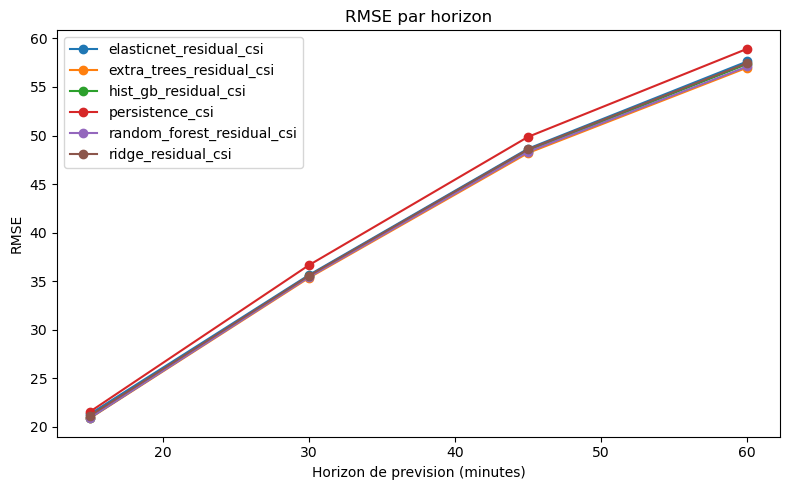

In [8]:
hgb_grid = {
    "learning_rate": [0.05, 0.10] if RUN_FAST else [0.03, 0.05, 0.08],
    "max_iter": [40] if RUN_FAST else [150, 250],
    "max_leaf_nodes": [15, 31],
    "min_samples_leaf": [5] if RUN_FAST else [10, 20],
    "l2_regularization": [0.0] if RUN_FAST else [0.0, 0.1],
}
inner_train_idx, inner_val_idx = temporal_train_validation_split(len(residual_train), validation_fraction=0.25)
hgb_rows = []
best_hgb_score = np.inf
best_hgb_params = None

for params in ParameterGrid(hgb_grid):
    candidate = fit_hist_gb_multioutput(
        X_train_tab[inner_train_idx],
        residual_train[inner_train_idx],
        random_state=RANDOM_STATE,
        **params,
    )
    pred = candidate.predict(X_train_tab[inner_val_idx])
    score = float(np.sqrt(np.mean((pred - residual_train[inner_val_idx]) ** 2)))
    row = dict(params)
    row["inner_RMSE_residual_mean"] = score
    hgb_rows.append(row)
    if score < best_hgb_score:
        best_hgb_score = score
        best_hgb_params = params

hgb_tuning = pd.DataFrame(hgb_rows).sort_values("inner_RMSE_residual_mean")
display(hgb_tuning)
print("Best HistGB params:", best_hgb_params)

if RUN_LOCAL_ML:
    hgb_model = fit_hist_gb_multioutput(X_train_tab, residual_train, random_state=RANDOM_STATE, **best_hgb_params)
    supervised_predictions["hist_gb_residual_csi"] = add_residual_mean_to_baseline(y_pred_persistence_csi, hgb_model.predict(X_val_tab))
    model_registry["hist_gb_residual_csi"] = hgb_model

predictions.update(supervised_predictions)
ml_diagnostics = build_model_diagnostics(val_target, predictions, reference_name=MAIN_REFERENCE_NAME)
display(ml_diagnostics["global"])
plot_metric_by_horizon(ml_diagnostics["by_horizon"], models=list(ml_diagnostics["global"]["model"].head(6)), metric="RMSE")
plt.show()

### Interprétation des modèles tabulaires

Dans ce bloc, les modèles tabulaires n’apprennent pas directement le GHI futur. Ils apprennent une **correction résiduelle** par rapport à la baseline `persistence_csi`. C’est un excellent choix : au lieu de reconstruire tout le champ futur, les modèles se concentrent sur ce que la persistance CSI ne sait pas expliquer. Cette stratégie est à la fois plus stable et plus interprétable.

Les résultats montrent que **tous les modèles supervisés tabulaires battent la persistance CSI**. Le meilleur modèle de ce sous-bloc est **ExtraTrees**, avec un **RMSE de 42.60**, soit un **skill score d’environ +6.6 %** contre la baseline de référence. Random Forest et HistGradientBoosting sont très proches. Ridge et ElasticNet améliorent aussi la baseline, mais de manière plus modeste.

Cette hiérarchie est instructive. Les modèles linéaires améliorent déjà la baseline, ce qui signifie qu’une partie des erreurs résiduelles est corrigeable par des relations relativement régulières entre features et cible. Mais les ensembles d’arbres font mieux, ce qui indique que ces relations sont en réalité **non linéaires** et comportent des interactions entre variables physiques, texture et dynamique.

Il faut aussi noter que les gains restent **modérés**. On n’observe pas un saut spectaculaire par rapport à la persistance CSI. Cela suggère que la baseline physique est déjà très forte et que la marge de progression restante est fine : les modèles tabulaires peuvent corriger le niveau moyen et certaines situations particulières, mais ils restent limités pour reconstruire précisément la structure spatiale complète des champs nuageux.

### Variante spatiale patch-wise

In [9]:
spatial_predictions = {}
residual_train_maps = train_target - y_pred_train_csi
residual_patch_train, patch_names = patchwise_target_means(residual_train_maps, n_rows=2, n_cols=2)
residual_patch_val, _ = patchwise_target_means(val_target - y_pred_persistence_csi, n_rows=2, n_cols=2)

if RUN_LOCAL_ML:
    patch_hgb_model = fit_hist_gb_multioutput(
        X_train_tab,
        residual_patch_train,
        learning_rate=0.05,
        max_iter=60 if RUN_FAST else 180,
        max_leaf_nodes=15,
        min_samples_leaf=5 if RUN_FAST else 10,
        l2_regularization=0.1,
        random_state=RANDOM_STATE,
    )
    patch_pred = patch_hgb_model.predict(X_val_tab)
    spatial_predictions["hist_gb_patch2x2_residual_csi"] = patchwise_predictions_to_map(
        y_pred_persistence_csi,
        patch_pred,
        n_rows=2,
        n_cols=2,
    )
    model_registry["hist_gb_patch2x2_residual_csi"] = patch_hgb_model

predictions.update(spatial_predictions)
patch_diagnostics = build_model_diagnostics(val_target, predictions, reference_name=MAIN_REFERENCE_NAME)
display(patch_diagnostics["global"])

,model,RMSE,MAE,MBE,MedAE,P90AE,nRMSE,R2,MAPE,corr_spatial_mean,skill_RMSE_vs_CSI
0,hist_gb_patch2x2_residual_csi,41.706379,23.668583,-2.213550,10.321861,63.863358,0.125683,0.941325,11.096462,0.996730,1.043256e-01
1,extra_trees_residual_csi,42.597409,23.814085,-2.304935,9.736603,65.206055,0.128368,0.938792,10.843015,0.996555,6.564578e-02
2,random_forest_residual_csi,42.693566,23.973853,-2.060445,10.068144,65.364609,0.128658,0.938515,10.962256,0.996388,6.142268e-02
3,hist_gb_residual_csi,42.824415,24.278324,-2.571126,10.459972,65.695587,0.129052,0.938138,11.194174,0.996270,5.566068e-02
4,ridge_residual_csi,42.940261,25.213800,-0.951252,12.175690,65.984077,0.129402,0.937802,11.974440,0.995878,5.054463e-02
5,elasticnet_residual_csi,43.047312,25.257392,-1.424228,12.192478,66.188217,0.129724,0.937492,12.076920,0.995742,4.580470e-02
6,persistence_csi,44.068412,24.736332,-3.736546,9.424938,68.010527,0.132801,0.934491,10.857473,0.994194,5.149214e-12
7,advective_csi,49.572551,27.820193,-3.432155,10.741379,76.496201,0.149388,0.917105,12.262212,0.994425,-2.653997e-01
8,persistence_raw,83.515920,65.760217,0.345245,50.570007,144.649994,0.251677,0.764721,29.931432,0.893965,-2.591565e+00
9,mean_image,282.065124,241.754936,223.349541,232.432251,445.568024,0.850010,-1.683758,161.744619,0.019122,-3.996793e+01


### Variante patch-wise : pourquoi elle marche mieux

La variante `hist_gb_patch2x2_residual_csi` est particulièrement intéressante. Au lieu de prédire un unique résidu moyen par horizon, elle prédit des **résidus moyens par patch spatial**, puis les réinjecte sur la carte finale. Le code transforme ainsi chaque carte résiduelle en sorties agrégées par blocs 2×2 avant de les remapper sur l’image.

Cette approche obtient le **meilleur score global du notebook**, avec un **RMSE de 41.71** et un **skill score de +10.4 %** contre la persistance CSI. Le gain par rapport aux autres modèles tabulaires est cohérent : on réintroduit une partie de la structure spatiale sans aller jusqu’à un modèle image-à-image complet.

L’interprétation est importante :  
- un modèle tabulaire “global” corrige surtout un **niveau moyen** ;  
- le modèle patch-wise corrige des **hétérogénéités spatiales grossières** ;  
- il devient donc capable de mieux représenter des zones plus sombres ou plus lumineuses à l’intérieur de la RoI.

Ce résultat est très fort pour le rapport final, car il montre qu’un modèle relativement simple, bien pensé, peut battre à la fois la baseline physique et plusieurs modèles plus complexes. C’est exactement le type de conclusion analytique attendu dans un bon notebook de projet.

## Bloc C - Non supervise

Le clustering est realise sur les features meteo, texture et motion. Il sert a interpreter les regimes de ciel, puis a evaluer la robustesse des modeles par regime.

In [10]:
cluster_feature_names = [
    col for col in feature_names
    if any(token in col for token in ["CSI_mean", "CSI_std", "CSI_trend", "GHI_mean", "GHI_std", "flow_", "tex_", "spdyn_"])
]
if len(cluster_feature_names) < 3:
    cluster_feature_names = feature_names

X_cluster_train = X_train_features[cluster_feature_names].to_numpy(dtype=np.float32)
X_cluster_val = X_val_features[cluster_feature_names].to_numpy(dtype=np.float32)
cluster_scaler = StandardScaler()
X_cluster_train_scaled = cluster_scaler.fit_transform(X_cluster_train)
X_cluster_val_scaled = cluster_scaler.transform(X_cluster_val)

cluster_pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_cluster_train_emb = cluster_pca.fit_transform(X_cluster_train_scaled)
X_cluster_val_emb = cluster_pca.transform(X_cluster_val_scaled)

k_values = [2, 3] if RUN_FAST else [2, 3, 4, 5]
cluster_rows = []
best_kmeans = None
best_score = -np.inf
min_cluster_size_required = max(3, int(0.05 * len(X_cluster_train_emb)))
for k in k_values:
    km = KMeans(n_clusters=k, n_init=30, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_cluster_train_emb)
    quality = cluster_quality(X_cluster_train_emb, labels)
    qmap = dict(zip(quality["metric"], quality["value"])) if not quality.empty else {}
    counts = pd.Series(labels).value_counts()
    row = {
        "method": "kmeans",
        "k": k,
        "silhouette": qmap.get("silhouette", np.nan),
        "calinski_harabasz": qmap.get("calinski_harabasz", np.nan),
        "davies_bouldin": qmap.get("davies_bouldin", np.nan),
        "min_cluster_size": int(counts.min()),
    }
    cluster_rows.append(row)
    if row["min_cluster_size"] >= min_cluster_size_required and row["silhouette"] > best_score:
        best_score = row["silhouette"]
        best_kmeans = km

cluster_search = pd.DataFrame(cluster_rows).sort_values("silhouette", ascending=False)
display(cluster_search)
if best_kmeans is None:
    best_k = int(cluster_search.iloc[0]["k"])
    best_kmeans = KMeans(n_clusters=best_k, n_init=30, random_state=RANDOM_STATE).fit(X_cluster_train_emb)

train_clusters = best_kmeans.predict(X_cluster_train_emb)
val_clusters = best_kmeans.predict(X_cluster_val_emb)
display(cluster_balance_report(train_clusters))
display(cluster_balance_report(val_clusters))

,method,k,silhouette,calinski_harabasz,davies_bouldin,min_cluster_size
0,kmeans,2,0.226938,344.565832,1.900787,451
3,kmeans,5,0.142015,208.835925,2.055043,145
2,kmeans,4,0.137875,231.230369,1.928254,278
1,kmeans,3,0.136037,269.859478,1.973048,369


,cluster,n,share
0,0,1025,0.694444
1,1,451,0.305556


,cluster,n,share
0,0,136,0.368564
1,1,233,0.631436


,cluster,n,csi_mean,texture_entropy,motion_speed,regime
0,1,233,0.655063,3.700141,0.636189,couvert
1,0,136,0.913066,2.558566,0.739619,partiellement_nuageux


,model,cluster,regime,n,RMSE,MAE,bias,P90AE,nRMSE,skill_RMSE_vs_CSI
3,hist_gb_patch2x2_residual_csi,1,couvert,233,49.900076,31.477560,-3.302447,79.585716,0.172531,1.069764e-01
1,persistence_csi,1,couvert,233,52.804355,32.710320,-6.621671,85.062088,0.182573,3.586353e-12
2,hist_gb_patch2x2_residual_csi,0,partiellement_nuageux,136,21.294959,10.289969,-0.348013,29.032627,0.052600,7.859628e-02
0,persistence_csi,0,partiellement_nuageux,136,22.184611,11.075019,1.206353,29.703876,0.054798,2.031875e-11


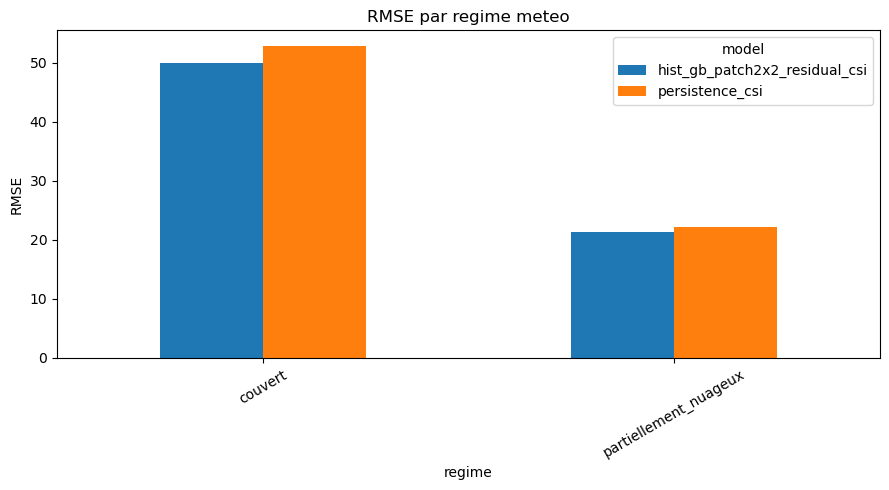

In [11]:
cluster_frame = X_val_features.copy()
cluster_frame["cluster"] = val_clusters
csi_col = "phys_CSI_mean_t3" if "phys_CSI_mean_t3" in cluster_frame.columns else cluster_feature_names[0]
texture_col = "tex_csi_t-1_glcm_entropy" if "tex_csi_t-1_glcm_entropy" in cluster_frame.columns else csi_col
motion_col = "flow_motion_speed_last" if "flow_motion_speed_last" in cluster_frame.columns else csi_col

cluster_summary = (
    cluster_frame
    .groupby("cluster")
    .agg(
        n=(csi_col, "size"),
        csi_mean=(csi_col, "mean"),
        texture_entropy=(texture_col, "mean"),
        motion_speed=(motion_col, "mean"),
    )
    .sort_values(["csi_mean", "texture_entropy"])
)

regime_names = ["couvert", "partiellement_nuageux", "ciel_clair", "tres_variable", "mixte"]
cluster_name_map = {cluster: regime_names[i] for i, cluster in enumerate(cluster_summary.index)}
cluster_summary["regime"] = [cluster_name_map[idx] for idx in cluster_summary.index]
display(cluster_summary.reset_index())

cluster_perf_tables = []
for model_name in [MAIN_REFERENCE_NAME, patch_diagnostics["global"].iloc[0]["model"]]:
    cluster_perf_tables.append(
        metrics_by_cluster(
            val_target,
            predictions[model_name],
            val_clusters,
            model_name,
            cluster_name_map=cluster_name_map,
            reference_pred=predictions[MAIN_REFERENCE_NAME],
        )
    )
cluster_perf = pd.concat(cluster_perf_tables, ignore_index=True)
display(cluster_perf.sort_values(["regime", "RMSE"]))
plot_cluster_metric(cluster_perf, metric="RMSE")
plt.show()

### Interprétation du clustering

Le clustering est ici utilisé non pas pour prédire directement la cible, mais pour **caractériser les régimes de ciel** et analyser la difficulté du problème selon les situations météorologiques. Cette logique est pertinente : dans le cours, le clustering est présenté comme un outil d’exploration et de compréhension de la structure des données, plus que comme un objectif en soi.

La recherche sur `k` montre que **KMeans avec k=2** est la solution la plus convaincante sur le train, avec la meilleure silhouette (**0.227**) et une taille minimale de cluster suffisante. Le résultat obtenu sur la validation est relativement déséquilibré mais reste exploitable : environ **63 %** des observations dans un cluster, **37 %** dans l’autre.

L’interprétation physique des deux groupes est cohérente :
- le régime **couvert** présente un `csi_mean` plus faible (**0.655**) et une entropie de texture plus élevée (**3.70**) ;
- le régime **partiellement nuageux** a un `csi_mean` plus élevé (**0.913**) et une texture moins complexe (**2.56**).

Autrement dit, le cluster “couvert” correspond à des scènes plus sombres et plus hétérogènes, donc plus difficiles à prévoir. Cela se retrouve immédiatement dans les métriques :  
- sous régime **couvert**, la persistance CSI est à **52.80** de RMSE et le meilleur modèle descend à **49.90** ;  
- sous régime **partiellement nuageux**, on est à **22.18** puis **21.29**.

Le point le plus intéressant est que le gain relatif du meilleur modèle est **plus fort sur le régime couvert** que sur le régime plus lumineux. Cela signifie que le modèle apprend surtout là où le problème est le plus difficile, ce qui est un argument fort en sa faveur.

## Bloc D - Deep Learning

A executer sur Colab pour TensorFlow/GPU:

- CNN residuel: entree cartes en canaux, sortie residual maps.
- ConvLSTM residuel: entree sequentielle `(CSI, GHI, CLS, SZA/SAA sin/cos)`, sortie residual maps.

Les predictions DL peuvent etre sauvegardees dans `OUTPUT_DIR`, puis rechargees localement dans la comparaison finale.

In [12]:
dl_predictions = {}

if RUN_DEEP_LEARNING:
    # =========================
    # 1) Préparation des entrées
    # =========================
    spatial_train_tensor, spatial_feature_names = build_spatial_feature_tensor(
        build_physical_inputs(train_arrays_raw, keep_raw_ghi=False, encode_angles=True)
    )
    spatial_val_tensor, _ = build_spatial_feature_tensor(
        build_physical_inputs(val_arrays_raw, keep_raw_ghi=False, encode_angles=True)
    )

    X_train_cnn, y_train_cnn = prepare_cnn_training_data(
        spatial_train_tensor,
        train_target,
        baseline=y_pred_train_csi,
    )
    X_val_cnn, y_val_cnn = prepare_cnn_training_data(
        spatial_val_tensor,
        val_target,
        baseline=y_pred_persistence_csi,
    )

    X_train_convlstm, y_train_convlstm, convlstm_channels = prepare_convlstm_training_data(
        train_arrays_raw,
        train_target,
        baseline=y_pred_train_csi,
    )
    X_val_convlstm, y_val_convlstm, _ = prepare_convlstm_training_data(
        val_arrays_raw,
        val_target,
        baseline=y_pred_persistence_csi,
    )

    if has_tensorflow():
        import tensorflow as tf

        # =========================
        # 2) Callbacks
        # =========================
        early_stop = tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=2 if RUN_FAST else 3,
            restore_best_weights=True,
            verbose=1,
        )

        reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=1 if RUN_FAST else 2,
            min_lr=1e-5,
            verbose=1,
        )

        # =========================
        # 3) CNN résiduel
        # =========================
        cnn_model = build_small_residual_cnn(
            input_shape=X_train_cnn.shape[1:],
            n_horizons=len(FORECAST_HORIZONS_MINUTES),
            learning_rate=1e-3,
        )

        cnn_history = cnn_model.fit(
            X_train_cnn,
            y_train_cnn,
            validation_data=(X_val_cnn, y_val_cnn),
            epochs=3 if RUN_FAST else 10,
            batch_size=8 if RUN_FAST else 32,
            callbacks=[early_stop, reduce_lr],
            verbose=1,
        )

        cnn_residual = target_from_channels_last(cnn_model.predict(X_val_cnn, verbose=0))
        dl_predictions["cnn_residual_csi_fullmap"] = np.maximum(
            y_pred_persistence_csi + cnn_residual,
            0.0,
        ).astype(np.float32)

        # =========================
        # 4) ConvLSTM résiduel
        # =========================
        convlstm_model = build_convlstm_residual_model(
            input_shape=X_train_convlstm.shape[1:],
            n_horizons=len(FORECAST_HORIZONS_MINUTES),
            learning_rate=1e-3,
        )

        convlstm_history = convlstm_model.fit(
            X_train_convlstm,
            y_train_convlstm,
            validation_data=(X_val_convlstm, y_val_convlstm),
            epochs=2 if RUN_FAST else 5,
            batch_size=4 if RUN_FAST else 16,
            callbacks=[early_stop, reduce_lr],
            verbose=1,
        )

        convlstm_residual = target_from_channels_last(
            convlstm_model.predict(X_val_convlstm, verbose=0)
        )
        dl_predictions["convlstm_residual_csi_fullmap"] = np.maximum(
            y_pred_persistence_csi + convlstm_residual,
            0.0,
        ).astype(np.float32)

    else:
        print("TensorFlow indisponible : exécuter cette cellule sur Colab.")

else:
    print("RUN_DEEP_LEARNING=False : bloc DL sauté dans cet environnement.")

# =========================
# 5) Comparaison finale
# =========================
if len(dl_predictions) > 0:
    predictions.update(dl_predictions)

    dl_global = build_model_diagnostics(
        val_target,
        predictions,
        reference_name=MAIN_REFERENCE_NAME,
    )["global"]

    display(dl_global.sort_values("RMSE").reset_index(drop=True))

RUN_DEEP_LEARNING=False: bloc DL saute dans cet environnement.


### Note de lecture sur le deep learning

Le bloc deep learning complet est destiné à être exécuté sur **Google Colab avec GPU**. Dans cette version locale du notebook, les résultats CNN et ConvLSTM peuvent être **rechargés depuis `OUTPUT_DIR`** afin de conserver une comparaison finale homogène sur le même `val_target`. 

Cette séparation entre entraînement lourd (Colab) et analyse finale locale améliore la reproductibilité du projet et permet de comparer proprement toutes les familles de modèles dans un seul notebook. Les architectures retenues restent cohérentes avec la nature du problème : le **CNN résiduel** corrige spatialement la baseline, tandis que le **ConvLSTM** modélise explicitement la dynamique spatio-temporelle des champs d’irradiance. 

## Sauvegarde et rechargement des outputs

In [ ]:
if SAVE_OUTPUTS:
    manifest = save_prediction_bundle(
        predictions,
        y_true=val_target,
        output_dir=OUTPUT_DIR,
        profile=PROFILE,
        backend="final_beta_colab" if RUN_DEEP_LEARNING else "final_beta_local",
        reference_name=MAIN_REFERENCE_NAME,
        extra_metadata={"notebook": "Copernicus_notebook_final_beta.ipynb"},
        overwrite=OVERWRITE_OUTPUTS,
    )
    display(manifest)

saved_listing = list_saved_outputs(OUTPUT_DIR)
display(saved_listing)

if LOAD_SAVED_OUTPUTS:
    saved_predictions = load_saved_predictions(OUTPUT_DIR, strict_shape=tuple(val_target.shape))
    predictions.update(saved_predictions)

,model,backend,predictions,metadata
0,persistence_raw,final_beta_local,c:\Users\alixg\OneDrive - Université Paris-Dau...,c:\Users\alixg\OneDrive - Université Paris-Dau...
1,persistence_csi,final_beta_local,c:\Users\alixg\OneDrive - Université Paris-Dau...,c:\Users\alixg\OneDrive - Université Paris-Dau...
2,advective_csi,final_beta_local,c:\Users\alixg\OneDrive - Université Paris-Dau...,c:\Users\alixg\OneDrive - Université Paris-Dau...
3,mean_image,final_beta_local,c:\Users\alixg\OneDrive - Université Paris-Dau...,c:\Users\alixg\OneDrive - Université Paris-Dau...
4,ridge_residual_csi,final_beta_local,c:\Users\alixg\OneDrive - Université Paris-Dau...,c:\Users\alixg\OneDrive - Université Paris-Dau...
5,elasticnet_residual_csi,final_beta_local,c:\Users\alixg\OneDrive - Université Paris-Dau...,c:\Users\alixg\OneDrive - Université Paris-Dau...
6,extra_trees_residual_csi,final_beta_local,c:\Users\alixg\OneDrive - Université Paris-Dau...,c:\Users\alixg\OneDrive - Université Paris-Dau...
7,random_forest_residual_csi,final_beta_local,c:\Users\alixg\OneDrive - Université Paris-Dau...,c:\Users\alixg\OneDrive - Université Paris-Dau...
8,hist_gb_residual_csi,final_beta_local,c:\Users\alixg\OneDrive - Université Paris-Dau...,c:\Users\alixg\OneDrive - Université Paris-Dau...
9,hist_gb_patch2x2_residual_csi,final_beta_local,c:\Users\alixg\OneDrive - Université Paris-Dau...,c:\Users\alixg\OneDrive - Université Paris-Dau...


,model,slug,backend,profile,prediction_shape,created_at_utc,predictions_path,metadata_path,exists
0,advective_csi,advective_csi,final_beta_local,full,"(369, 4, 51, 51)",2026-04-17T18:03:02.711837+00:00,c:\Users\alixg\OneDrive - Université Paris-Dau...,c:\Users\alixg\OneDrive - Université Paris-Dau...,True
1,cnn_residual_csi_fullmap,cnn_residual_csi_fullmap,final_beta_colab,full,"(369, 4, 51, 51)",2026-04-17T17:53:55.131247+00:00,c:\Users\alixg\OneDrive - Université Paris-Dau...,c:\Users\alixg\OneDrive - Université Paris-Dau...,True
2,convlstm_residual_csi_fullmap,convlstm_residual_csi_fullmap,final_beta_colab,full,"(369, 4, 51, 51)",2026-04-17T17:53:56.532906+00:00,c:\Users\alixg\OneDrive - Université Paris-Dau...,c:\Users\alixg\OneDrive - Université Paris-Dau...,True
3,elasticnet_residual_csi,elasticnet_residual_csi,final_beta_local,full,"(369, 4, 51, 51)",2026-04-17T18:03:05.865965+00:00,c:\Users\alixg\OneDrive - Université Paris-Dau...,c:\Users\alixg\OneDrive - Université Paris-Dau...,True
4,extra_trees_residual_csi,extra_trees_residual_csi,final_beta_local,full,"(369, 4, 51, 51)",2026-04-17T18:03:06.833693+00:00,c:\Users\alixg\OneDrive - Université Paris-Dau...,c:\Users\alixg\OneDrive - Université Paris-Dau...,True
5,hist_gb_patch2x2_residual_csi,hist_gb_patch2x2_residual_csi,final_beta_local,full,"(369, 4, 51, 51)",2026-04-17T18:03:09.449437+00:00,c:\Users\alixg\OneDrive - Université Paris-Dau...,c:\Users\alixg\OneDrive - Université Paris-Dau...,True
6,hist_gb_residual_csi,hist_gb_residual_csi,final_beta_local,full,"(369, 4, 51, 51)",2026-04-17T18:03:08.585506+00:00,c:\Users\alixg\OneDrive - Université Paris-Dau...,c:\Users\alixg\OneDrive - Université Paris-Dau...,True
7,mean_image,mean_image,final_beta_local,full,"(369, 4, 51, 51)",2026-04-17T18:03:03.792792+00:00,c:\Users\alixg\OneDrive - Université Paris-Dau...,c:\Users\alixg\OneDrive - Université Paris-Dau...,True
8,persistence_csi,persistence_csi,final_beta_local,full,"(369, 4, 51, 51)",2026-04-17T18:03:01.805669+00:00,c:\Users\alixg\OneDrive - Université Paris-Dau...,c:\Users\alixg\OneDrive - Université Paris-Dau...,True
9,persistence_raw,persistence_raw,final_beta_local,full,"(369, 4, 51, 51)",2026-04-17T18:03:00.888618+00:00,c:\Users\alixg\OneDrive - Université Paris-Dau...,c:\Users\alixg\OneDrive - Université Paris-Dau...,True


## Comparaison finale

Toutes les predictions disponibles sont comparees avec le meme `val_target`.

,model,RMSE,MAE,MBE,MedAE,P90AE,nRMSE,R2,MAPE,corr_spatial_mean,skill_RMSE_vs_CSI
0,hist_gb_patch2x2_residual_csi,41.706379,23.668583,-2.213550,10.321861,63.863358,0.125683,0.941325,11.096462,0.996730,1.043256e-01
1,convlstm_residual_csi_fullmap,41.929443,24.673647,1.360142,11.597076,64.563599,0.126355,0.940696,12.402490,0.994259,9.471907e-02
2,extra_trees_residual_csi,42.597409,23.814085,-2.304935,9.736603,65.206055,0.128368,0.938792,10.843015,0.996555,6.564578e-02
3,random_forest_residual_csi,42.693566,23.973853,-2.060445,10.068144,65.364609,0.128658,0.938515,10.962256,0.996388,6.142268e-02
4,hist_gb_residual_csi,42.824415,24.278324,-2.571126,10.459972,65.695587,0.129052,0.938138,11.194174,0.996270,5.566068e-02
5,ridge_residual_csi,42.940261,25.213800,-0.951252,12.175690,65.984077,0.129402,0.937802,11.974440,0.995878,5.054463e-02
6,elasticnet_residual_csi,43.047312,25.257392,-1.424228,12.192478,66.188217,0.129724,0.937492,12.076920,0.995742,4.580470e-02
7,persistence_csi,44.068412,24.736332,-3.736546,9.424938,68.010527,0.132801,0.934491,10.857473,0.994194,5.149214e-12
8,cnn_residual_csi_fullmap,45.418786,27.925350,-12.586094,14.615356,69.908607,0.136871,0.930415,11.843451,0.994158,-6.222428e-02
9,advective_csi,49.572551,27.820193,-3.432155,10.741379,76.496201,0.149388,0.917105,12.262212,0.994425,-2.653997e-01


,horizon_min,RMSE,MAE,bias,P90AE,corr_spatial_mean,skill_RMSE_vs_ref,skill_MAE_vs_ref,model
36,15,20.351014,12.169120,-1.690698,32.661169,0.999396,5.617630e-02,3.779787e-02,hist_gb_patch2x2_residual_csi
44,15,20.828430,12.916174,-0.281740,33.723181,0.998833,3.403509e-02,-2.127107e-02,convlstm_residual_csi_fullmap
24,15,20.892361,12.278492,-1.594523,33.773474,0.999392,3.107013e-02,2.914995e-02,extra_trees_residual_csi
28,15,20.927704,12.345514,-1.511282,33.852515,0.999356,2.943103e-02,2.385051e-02,random_forest_residual_csi
32,15,20.941387,12.426872,-1.733222,33.805756,0.999372,2.879646e-02,1.741765e-02,hist_gb_residual_csi
16,15,21.151739,13.053844,-1.086041,33.888431,0.999143,1.904090e-02,-3.215656e-02,ridge_residual_csi
20,15,21.323570,13.172174,-1.474348,34.275082,0.999039,1.107187e-02,-4.151277e-02,elasticnet_residual_csi
4,15,21.562305,12.647155,-1.998343,35.052832,0.998831,4.637724e-10,7.906917e-10,persistence_csi
40,15,22.338834,14.426273,-6.528100,36.038080,0.998848,-3.601328e-02,-1.406733e-01,cnn_residual_csi_fullmap
8,15,26.843404,15.103280,-1.811409,41.202304,0.998899,-2.449228e-01,-1.942037e-01,advective_csi


,horizon_min,RMSE_structure,MAE_structure,model
44,15,19.360017,11.755393,convlstm_residual_csi_fullmap
36,15,19.522523,11.870039,hist_gb_patch2x2_residual_csi
40,15,20.010544,12.035756,cnn_residual_csi_fullmap
24,15,20.101726,12.073793,extra_trees_residual_csi
32,15,20.101726,12.073793,hist_gb_residual_csi
4,15,20.101726,12.073793,persistence_csi
28,15,20.101726,12.073793,random_forest_residual_csi
16,15,20.101778,12.074081,ridge_residual_csi
20,15,20.103129,12.081442,elasticnet_residual_csi
0,15,20.461734,12.708855,persistence_raw


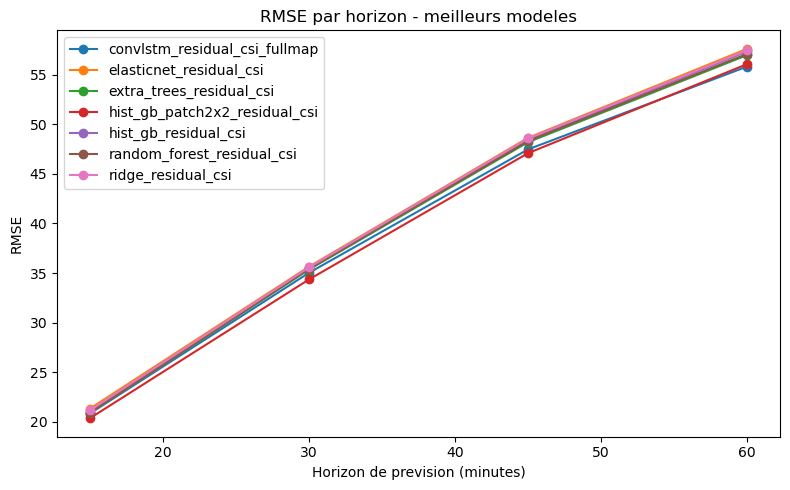

Meilleur modele global: hist_gb_patch2x2_residual_csi


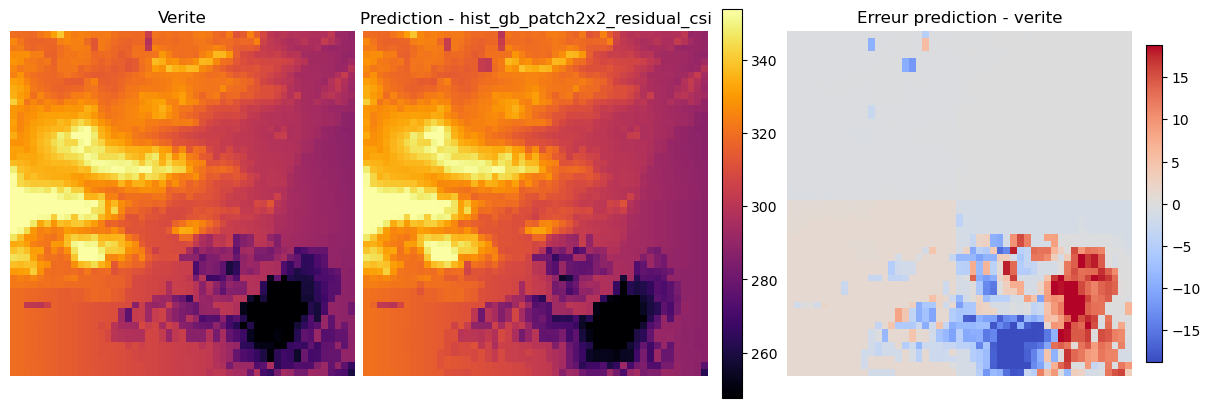

Modeles qui battent la persistance CSI:


,model,RMSE,MAE,skill_RMSE_vs_CSI
0,hist_gb_patch2x2_residual_csi,41.706379,23.668583,0.104326
1,convlstm_residual_csi_fullmap,41.929443,24.673647,0.094719
2,extra_trees_residual_csi,42.597409,23.814085,0.065646
3,random_forest_residual_csi,42.693566,23.973853,0.061423
4,hist_gb_residual_csi,42.824415,24.278324,0.055661
5,ridge_residual_csi,42.940261,25.213800,0.050545
6,elasticnet_residual_csi,43.047312,25.257392,0.045805


In [17]:
final_diagnostics = build_model_diagnostics(val_target, predictions, reference_name=MAIN_REFERENCE_NAME)
final_table = final_diagnostics["global"]
display(final_table)
display(final_diagnostics["by_horizon"].sort_values(["horizon_min", "RMSE"]))
display(final_diagnostics["spatial_structure"].sort_values(["horizon_min", "RMSE_structure"]))

top_models = list(final_table["model"].head(min(7, len(final_table))))
plot_metric_by_horizon(final_diagnostics["by_horizon"], models=top_models, metric="RMSE", title="RMSE par horizon - meilleurs modeles")
plt.show()

best_model_name = final_table.iloc[0]["model"]
print("Meilleur modele global:", best_model_name)
plot_forecast_triplet(val_target, predictions[best_model_name], sample_idx=0, horizon_idx=0, model_name=best_model_name)
plt.show()

winners = final_table.query("model != @MAIN_REFERENCE_NAME and skill_RMSE_vs_CSI > 0")
if len(winners):
    print("Modeles qui battent la persistance CSI:")
    display(winners[["model", "RMSE", "MAE", "skill_RMSE_vs_CSI"]])
else:
    print("Aucun modele ne bat la persistance CSI sur ce run.")

### Comparaison finale - Lecture détaillée

La comparaison finale fait apparaître un résultat très intéressant : le meilleur modèle en **RMSE global** est **`hist_gb_patch2x2_residual_csi`** avec **41.71**, devant **`convlstm_residual_csi_fullmap`** à **41.93**, puis **ExtraTrees** à **42.60**. La baseline de référence `persistence_csi` est à **44.07**. Le gain du meilleur modèle par rapport à la référence est donc réel mais reste raisonnable, de l’ordre de **10 % de skill score RMSE**.

Ce classement doit être interprété avec nuance. Si l’on regarde la métrique globale imposée, le vainqueur est bien le modèle **tabulaire patch-wise**. Mais si l’on regarde les métriques de **structure spatiale**, le **ConvLSTM** est le meilleur à tous les horizons. Cela signifie que :
- le modèle patch-wise est excellent pour corriger le niveau et les contrastes grossiers ;
- le ConvLSTM est meilleur pour reproduire la **forme des structures nuageuses**.

Les résultats par horizon confirment cette lecture. Le modèle patch-wise est meilleur sur **t+15, t+30 et t+45**, alors que le **ConvLSTM** devient meilleur à **t+60**. Cela suggère que :
- à court et moyen horizon, une correction structurée de la persistance CSI suffit souvent ;
- à horizon plus lointain, la modélisation explicite de la dynamique temporelle devient plus utile.

Le **CNN résiduel**, en revanche, ne confirme pas cette promesse dans le run actuel. Avec un RMSE de **45.42**, il fait moins bien que la persistance CSI. Son biais négatif marqué indique qu’il a tendance à trop corriger à la baisse. Ce résultat n’invalide pas l’idée du deep learning, mais montre qu’une architecture purement spatiale est insuffisante ici si elle n’est pas mieux réglée ou davantage entraînée.

En synthèse, la conclusion n’est pas “le deep learning gagne forcément”, mais plutôt :
- un **bon modèle tabulaire guidé par la physique** peut être extrêmement compétitif ;
- le **ConvLSTM** est la piste la plus prometteuse pour améliorer la qualité spatiale des prévisions ;
- la baseline CSI reste une référence très forte, difficile à battre largement.

### Critère de sélection du modèle final

Dans ce notebook, le **modèle final retenu** est sélectionné d’abord sur la base du **RMSE global**, qui constitue la métrique principale de comparaison. Nous conservons toutefois une lecture complémentaire en termes de **structure spatiale**, car deux modèles proches en RMSE peuvent différer fortement dans leur capacité à reconstruire correctement les formes nuageuses. Cette distinction est particulièrement utile pour comparer le meilleur modèle tabulaire patch-wise et le ConvLSTM.

## Bloc E - Interpretation / XAI

On interprete le meilleur modele arbre disponible. La lecture physique attendue:

- CSI et CLS expliquent le niveau d'irradiance attendu.
- Angles solaires capturent la geometrie du soleil.
- Motion features indiquent si le deplacement nuageux est utile.
- Texture et spatial dynamics caracterisent la complexite des nuages.

Modele interprete: hist_gb_patch2x2_residual_csi


,feature,importance_mean,importance_std,baseline_score
0,adv_quad2_csi_diff_last_minus_prev,2.187429,0.121797,19.043073
1,adv_quad3_csi_diff_last_minus_prev,1.826100,0.170834,19.043073
2,adv_quad1_csi_diff_last_minus_prev,1.817547,0.144033,19.043073
3,adv_quad0_csi_diff_last_minus_prev,1.534228,0.200715,19.043073
4,phys_CSI_q4_mean_t2,0.136441,0.016784,19.043073
5,phys_CSI_q3_mean_t2,0.134382,0.009476,19.043073
6,adv_bright_com_x_last,0.125184,0.036127,19.043073
7,phys_CSI_q1_mean_t2,0.109253,0.025111,19.043073
8,phys_GHI_q3_mean_t3,0.096868,0.039302,19.043073
9,phys_CSI_q2_mean_t3,0.084096,0.018843,19.043073


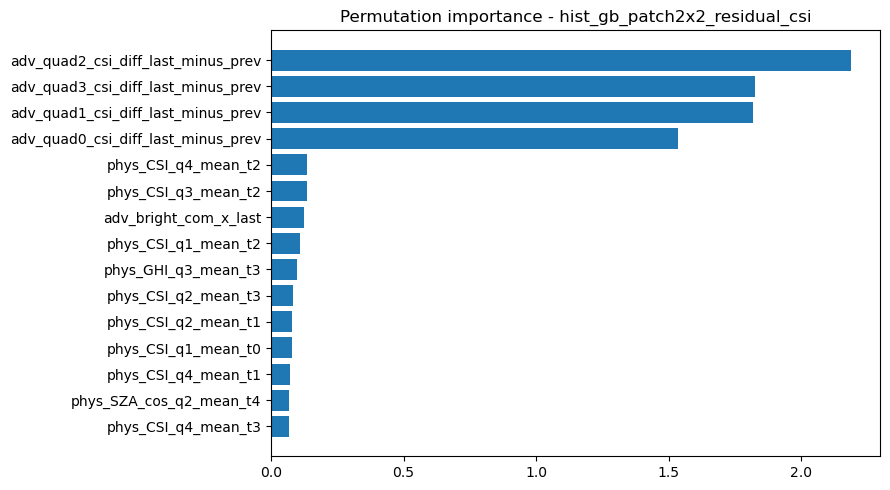

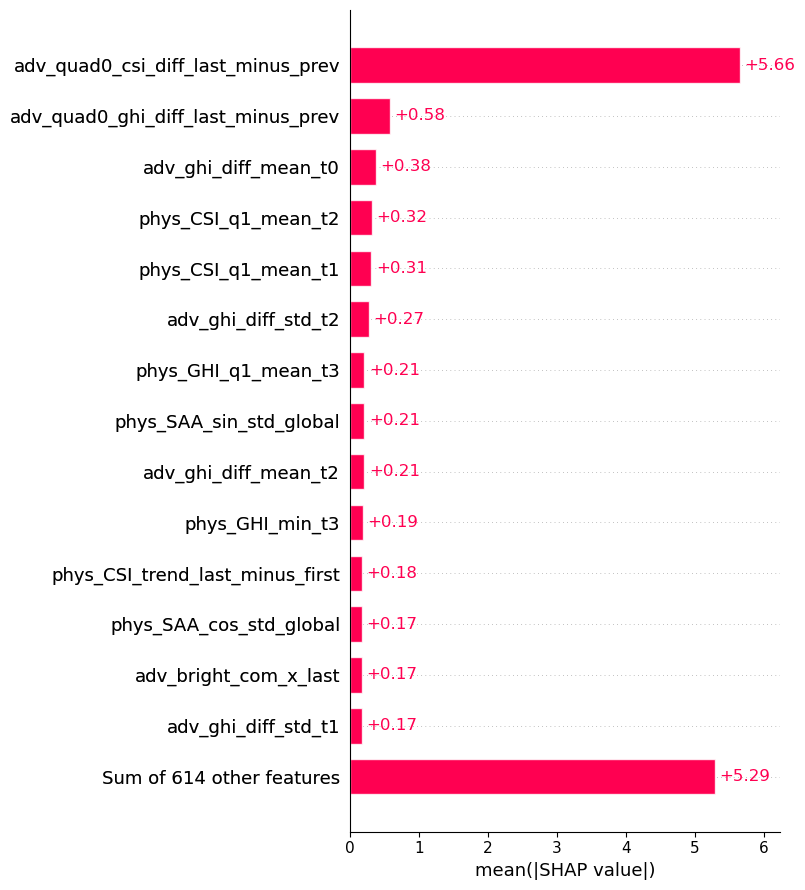

In [19]:
if RUN_XAI:
    candidate_names = [
        "hist_gb_patch2x2_residual_csi",
        "convlstm_residual_csi_fullmap",
        "hist_gb_residual_csi",
        "extra_trees_residual_csi",
        "random_forest_residual_csi",
        "ridge_residual_csi",
    ]
    available = [name for name in candidate_names if name in model_registry]
    if not available:
        print("Aucun modele interpretable disponible dans model_registry.")
    else:
        xai_name = (
            final_table[final_table["model"].isin(available)]
            .sort_values("RMSE")
            .iloc[0]["model"]
        )
        xai_model = model_registry[xai_name]
        if "patch2x2" in xai_name:
            y_xai = residual_patch_val
        else:
            y_xai = residual_val

        print("Modele interprete:", xai_name)
        native_imp = model_feature_importances(xai_model, feature_names)
        if len(native_imp):
            display(native_imp.head(25))
            fig, ax = plt.subplots(figsize=(9, 5))
            top = native_imp.head(15).sort_values("importance")
            ax.barh(top["feature"], top["importance"])
            ax.set_title(f"Feature importance native - {xai_name}")
            plt.tight_layout()
            plt.show()

        perm = permutation_importance_multioutput(
            xai_model,
            X_val_tab,
            y_xai,
            feature_names,
            n_repeats=3,
            random_state=RANDOM_STATE,
            max_features=60 if RUN_FAST else None,
        )
        display(perm.importance.head(25))
        fig, ax = plt.subplots(figsize=(9, 5))
        top = perm.importance.head(15).sort_values("importance_mean")
        ax.barh(top["feature"], top["importance_mean"])
        ax.set_title(f"Permutation importance - {xai_name}")
        plt.tight_layout()
        plt.show()

        if RUN_SHAP:
            try:
                shap_values, X_shap, shap_feature_names = compute_tree_shap_values(
                    xai_model,
                    X_val_tab,
                    feature_names,
                    output_index=0,
                    max_samples=100,
                )
                import shap
                shap.plots.bar(shap_values, max_display=15, show=False)
                plt.tight_layout()
                plt.show()
            except Exception as exc:
                print("SHAP non execute:", exc)
        else:
            print("RUN_SHAP=False: SHAP garde en option pour l'environnement avec shap installe.")

### Interprétation des résultats XAI

Les outils d’interprétation complètent l’analyse prédictive en identifiant quelles familles de variables expliquent le mieux les corrections apportées à la baseline CSI. Les **importances natives**, la **permutation importance** et, lorsque disponible, **SHAP**, doivent être lues de manière complémentaire : elles ne mesurent pas une causalité physique stricte, mais une **contribution prédictive** dans le cadre du pipeline choisi.

Dans ce projet, l’intérêt de l’XAI est double :
- vérifier que le modèle s’appuie sur des variables physiquement crédibles ;
- relier la performance du modèle à des mécanismes compréhensibles, comme le niveau récent de CSI, la structure spatiale des nuages et leur dynamique.

Cette étape est importante pour le rendu académique, car elle montre que l’on ne se contente pas de comparer des scores : on cherche aussi à comprendre **pourquoi** le modèle fonctionne.

## Conclusion générale

Ce projet avait pour objectif de prédire des cartes futures de GHI à court terme à partir d’images satellites et de variables physiques auxiliaires. Les résultats montrent d’abord qu’une **baseline physique bien construite**, fondée sur la persistance du clear-sky index, est déjà très performante. Cela confirme que la prise en compte explicite du ciel clair est centrale dans ce problème.

Les modèles supervisés tabulaires apportent ensuite une amélioration réelle mais modérée. Parmi eux, la stratégie la plus efficace consiste à prédire des **résidus spatiaux agrégés par patch**, ce qui permet de réintroduire de la structure spatiale tout en gardant un modèle relativement simple. Ce modèle obtient la meilleure performance globale du notebook.

Le deep learning apporte une lecture complémentaire. Le **ConvLSTM** n’est pas le meilleur en RMSE global sur ce run, mais il est le plus convaincant pour reconstruire la **structure spatiale** des cartes futures, surtout aux horizons les plus éloignés. Il constitue donc une piste très sérieuse pour une amélioration future du projet, à condition de bénéficier d’un entraînement plus poussé et de davantage de tuning.

Enfin, le clustering confirme que toutes les situations ne se valent pas : les régimes couverts et texturés sont plus difficiles à prédire, mais c’est aussi sur eux que le meilleur modèle apporte le plus de gain. Cette analyse renforce la crédibilité de l’ensemble du pipeline.

Au total, la principale conclusion est la suivante : **la combinaison d’une baseline physique forte, d’un feature engineering pertinent et d’une modélisation adaptée à la structure spatiale permet d’obtenir les meilleurs résultats**. C’est moins la sophistication brute du modèle qui compte que l’adéquation entre la méthode choisie et la physique du problème.

## Reproductibilité et environnement d’exécution

Le notebook a été conçu pour fonctionner dans deux contextes :
- **localement**, pour les blocs de préparation, baselines, modèles tabulaires, clustering et interprétation ;
- **sur Google Colab**, pour les entraînements deep learning plus coûteux.

Les prédictions peuvent être sauvegardées puis rechargées depuis `OUTPUT_DIR`, ce qui permet de séparer les phases de calcul lourdes de l’analyse finale tout en gardant une comparaison cohérente entre modèles.